## Change of variable

Suppose we have a posterior distribution of $\theta_1,\ \theta_2$ given by
$$
p(\theta_1, \theta_2 \mid d) 
$$
and we would like to transform it into the distribution of $\vartheta_1,\ \vartheta_2$, then by the change of variable formula, it amounts to:
$$
p(\vartheta_1, \vartheta_2 \mid d) = 
\vert J \vert \,
p(\theta_1, \theta_2 \mid d)
$$
where $\vert J \vert $ is the Jacobian:
$$
\vert J \vert = 
\begin{vmatrix}
\frac{\partial \theta_1}{\partial \vartheta_1} & \frac{\partial \theta_2}{\partial \vartheta_1} \\
\frac{\partial \theta_1}{\partial \vartheta_2} & \frac{\partial \theta_2}{\partial \vartheta_2} \\
\end{vmatrix}
$$

In [3]:
import jax
jax.config.update("jax_enable_x64", True)
from jax.lax import integer_pow
from gwfast.gwfastGlobals import DAY_TO_SEC
from gwfast.lensing_utils_alt import compute_lensed_angles_approx

from pathlib import Path
from jax import config
import jax.numpy as np
import numpy as onp
from jax.lax import broadcast_in_dim
config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MTSUN_SI, DAY_TO_SEC
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
import gwfast.network as network
from gwfast.signals import AGNLensedGWSignal
from gwfast.fisherTools import (
    reduce_Fisher_matrix, 
    plot_corners, compute_covariance_matrix, print_matrices
)


/users/hin-wai.leong/src/AGN-gwfast/gwfast/waveforms.py:35: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [4]:
def lensing_transform(lensing_parameters):
    # A fiducial phase which does not affect the Jacobian results
    lensing_parameters['phase'] = 0.0
    outputs = compute_lensed_angles_approx(lensing_parameters)
    phenom_changes = {}
    phenom_changes['delta_incl'] = outputs['iota_p'] - outputs['iota_m']
    phenom_changes['delta_phi'] = outputs['phase_p'] - outputs['phase_m']

    # (Radial gravitational potential is cancelled)
    phenom_changes['relative_mass'] = (1 + outputs['z_rel_p']) / (1 + outputs['z_rel_m'])
    relative_magification = outputs['sqrt_mu_m'] / outputs['sqrt_mu_p']
    phenom_changes['relative_distance'] = relative_magification * integer_pow((1 + outputs['z_rel_p']) / (1 + outputs['z_rel_m']), 2)
    phenom_changes['delta_time'] = outputs['delta_time'] / DAY_TO_SEC
    return phenom_changes


def m1m2_from_Mceta(Mc, eta):
    """
    Compute the component masses of a binary given its chirp mass and symmetric mass ratio.

    :param array or float Mc: Chirp mass of the binary, :math:`{\cal M}_c`.
    :param array or float eta: The symmetric mass ratio(s), :math:`\eta`, of the objects.
    :return: :math:`m_1` and :math:`m_2`.
    :rtype: tuple(array, array) or tuple(float, float)

    """
    delta = 1 - 4 * eta
    return (1 + np.sqrt(delta)) / 2 * Mc / eta ** (3.0 / 5.0), (
        1 - np.sqrt(delta)
    ) / 2 * Mc / eta ** (3.0 / 5.0)

In [7]:
jax.jacfwd(lensing_transform)({
    'iota': np.pi/2 * 0.97, 'phase': 0.4, 'R_orbit': 300., 'src_pos': 0.1, 
    'M_lz': 1e6, 'dL': 1.
})

{'delta_incl': {'M_lz': Array(1.12475993e-21, dtype=float64),
  'R_orbit': Array(0.00012771, dtype=float64),
  'dL': Array(-1.29150524e-15, dtype=float64),
  'iota': Array(1.62842118, dtype=float64),
  'phase': Array(0., dtype=float64),
  'src_pos': Array(0.77397965, dtype=float64)},
 'delta_phi': {'M_lz': Array(2.11914882e-21, dtype=float64),
  'R_orbit': Array(0.00024061, dtype=float64),
  'dL': Array(-2.43331198e-15, dtype=float64),
  'iota': Array(-0.85941522, dtype=float64),
  'phase': Array(0., dtype=float64),
  'src_pos': Array(-0.41171121, dtype=float64)},
 'delta_time': {'M_lz': Array(-4.95383508e-10, dtype=float64),
  'R_orbit': Array(-9.14259276e-07, dtype=float64),
  'dL': Array(7.34404525e-05, dtype=float64),
  'iota': Array(-0., dtype=float64),
  'phase': Array(-0., dtype=float64),
  'src_pos': Array(-0.00551326, dtype=float64)},
 'relative_distance': {'M_lz': Array(3.80053695e-21, dtype=float64),
  'R_orbit': Array(-0.00052739, dtype=float64),
  'dL': Array(3.20865654e-1

## Actually test it on a Fisher matrix

In [5]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device cou

In [6]:
shape = 3
lensing_parameters = {
    'Mc': 80, 'eta': 0.23, 'iota': 0.99 * np.pi / 2, 'phase': 2.1,
    'chi1z': 0.3, 'chi2z': 0.4, 'tcoal': 0.0,
    'theta': 0.1, 'phi': 0.3, 'psi': 0.3, 'dL': 2.0, 
    'R_orbit': 100, 'M_lz': 5e5, 'src_pos': 0.2
}
lensing_parameters = {key: np.full(shape, val).astype(np.float64) for key, val in lensing_parameters.items()}
lensing_parameters['src_pos'] = - np.arange(1, 6, 2) * 0.05

HLV_fisher = HLV_AGN.FisherMatr(lensing_parameters, res=1000)

trans_lensing_parameters = lensing_parameters.copy()
Mc = trans_lensing_parameters.pop('Mc')
eta = trans_lensing_parameters.pop('eta')

m1, m2 = m1m2_from_Mceta(Mc, eta)
trans_lensing_parameters['m1'] = m1
trans_lensing_parameters['m2'] = m2
trans_lensing_parameters = {
    key: np.full(shape, val).astype(np.float64) for key, val in trans_lensing_parameters.items()
}

trans_HLV_fisher = HLV_AGN.FisherMatr(trans_lensing_parameters, res=1000)

Computing Fisher for H1...
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 6.6859710754931845, Maximum duration: 32.75541455272001.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 17.65215266133077, Maximum duration: 32.75541455272001.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 30.640940863459154, Maximum duration: 32.75541455272001.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 6.6859710754931845, Maximum duration: 32.75541455272001.

Warning! Some of the input parameters will likely yield waveforms with signal length longer th

In [7]:
keys = list(lensing_parameters.keys()).copy()
reduce_fisher_mat, _ = reduce_Fisher_matrix(HLV_fisher, keys=keys)
# Convert to regular numpy for float128 support
reduce_fisher_mat = onp.array(reduce_fisher_mat)
reduced_cov_mats, ie = compute_covariance_matrix(reduce_fisher_mat)

# dt_idx = keys.index('delta_time')
# # Convert delta_time from days to seconds
# reduced_cov_mats[dt_idx, :, :] *= DAY_TO_SEC
# reduced_cov_mats[:, dt_idx, :] *= DAY_TO_SEC

labels = {
    'm1': r'$m_1\,/\,M_\odot$',
    'm2': r'$m_2\,/\,M_\odot$',
    'Mc': r'${\cal M}\,/\,M_\odot$',
    'eta': r'$\eta$',
    'dL': r'$D_{\rm L}\,/\,{\rm Gpc}$',
    'theta': r'$\alpha\,/\,{\rm rad}$',
    'phi': r'$\delta\,/\,{\rm rad}$',
    'iota': r'$\iota\,/\,{\rm rad}$',
    'psi': r'$\psi\,/\,{\rm rad}$',
    'tcoal': r'$t_{\rm c}\,/\,{\rm s}$',
    'phase': r'$\phi\,/\,{\rm rad}$',
    'chi1z': r'$\chi_{1z}$',
    'chi2z': r'$\chi_{2z}$',
    'R_orbit': r'$R_{\rm orb}\,/\,R_{\rm S}$',
    'M_lz': r'$M_{\rm Lz}\,/\,M_\odot$',
    'src_pos': r'$y$',
    'delta_iota': r'$\Delta \iota\,/\,{\rm rad}$',
    'delta_phase': r'$\Delta \phi\,/\,{\rm rad}$',
    'delta_phi': r'$\Delta \phi\,/\,{\rm rad}$',
    'delta_time': r'$\Delta t\,/\,{\rm s}$',
    'relative_mass': r'${\cal M}_2 \,/\,{\cal M}_1$',
    'relative_distance': r'$D_{L,2} \,/\,D_{L,1}$',
}

/users/hin-wai.leong/.conda/envs/180125_py311_AGNLensing/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


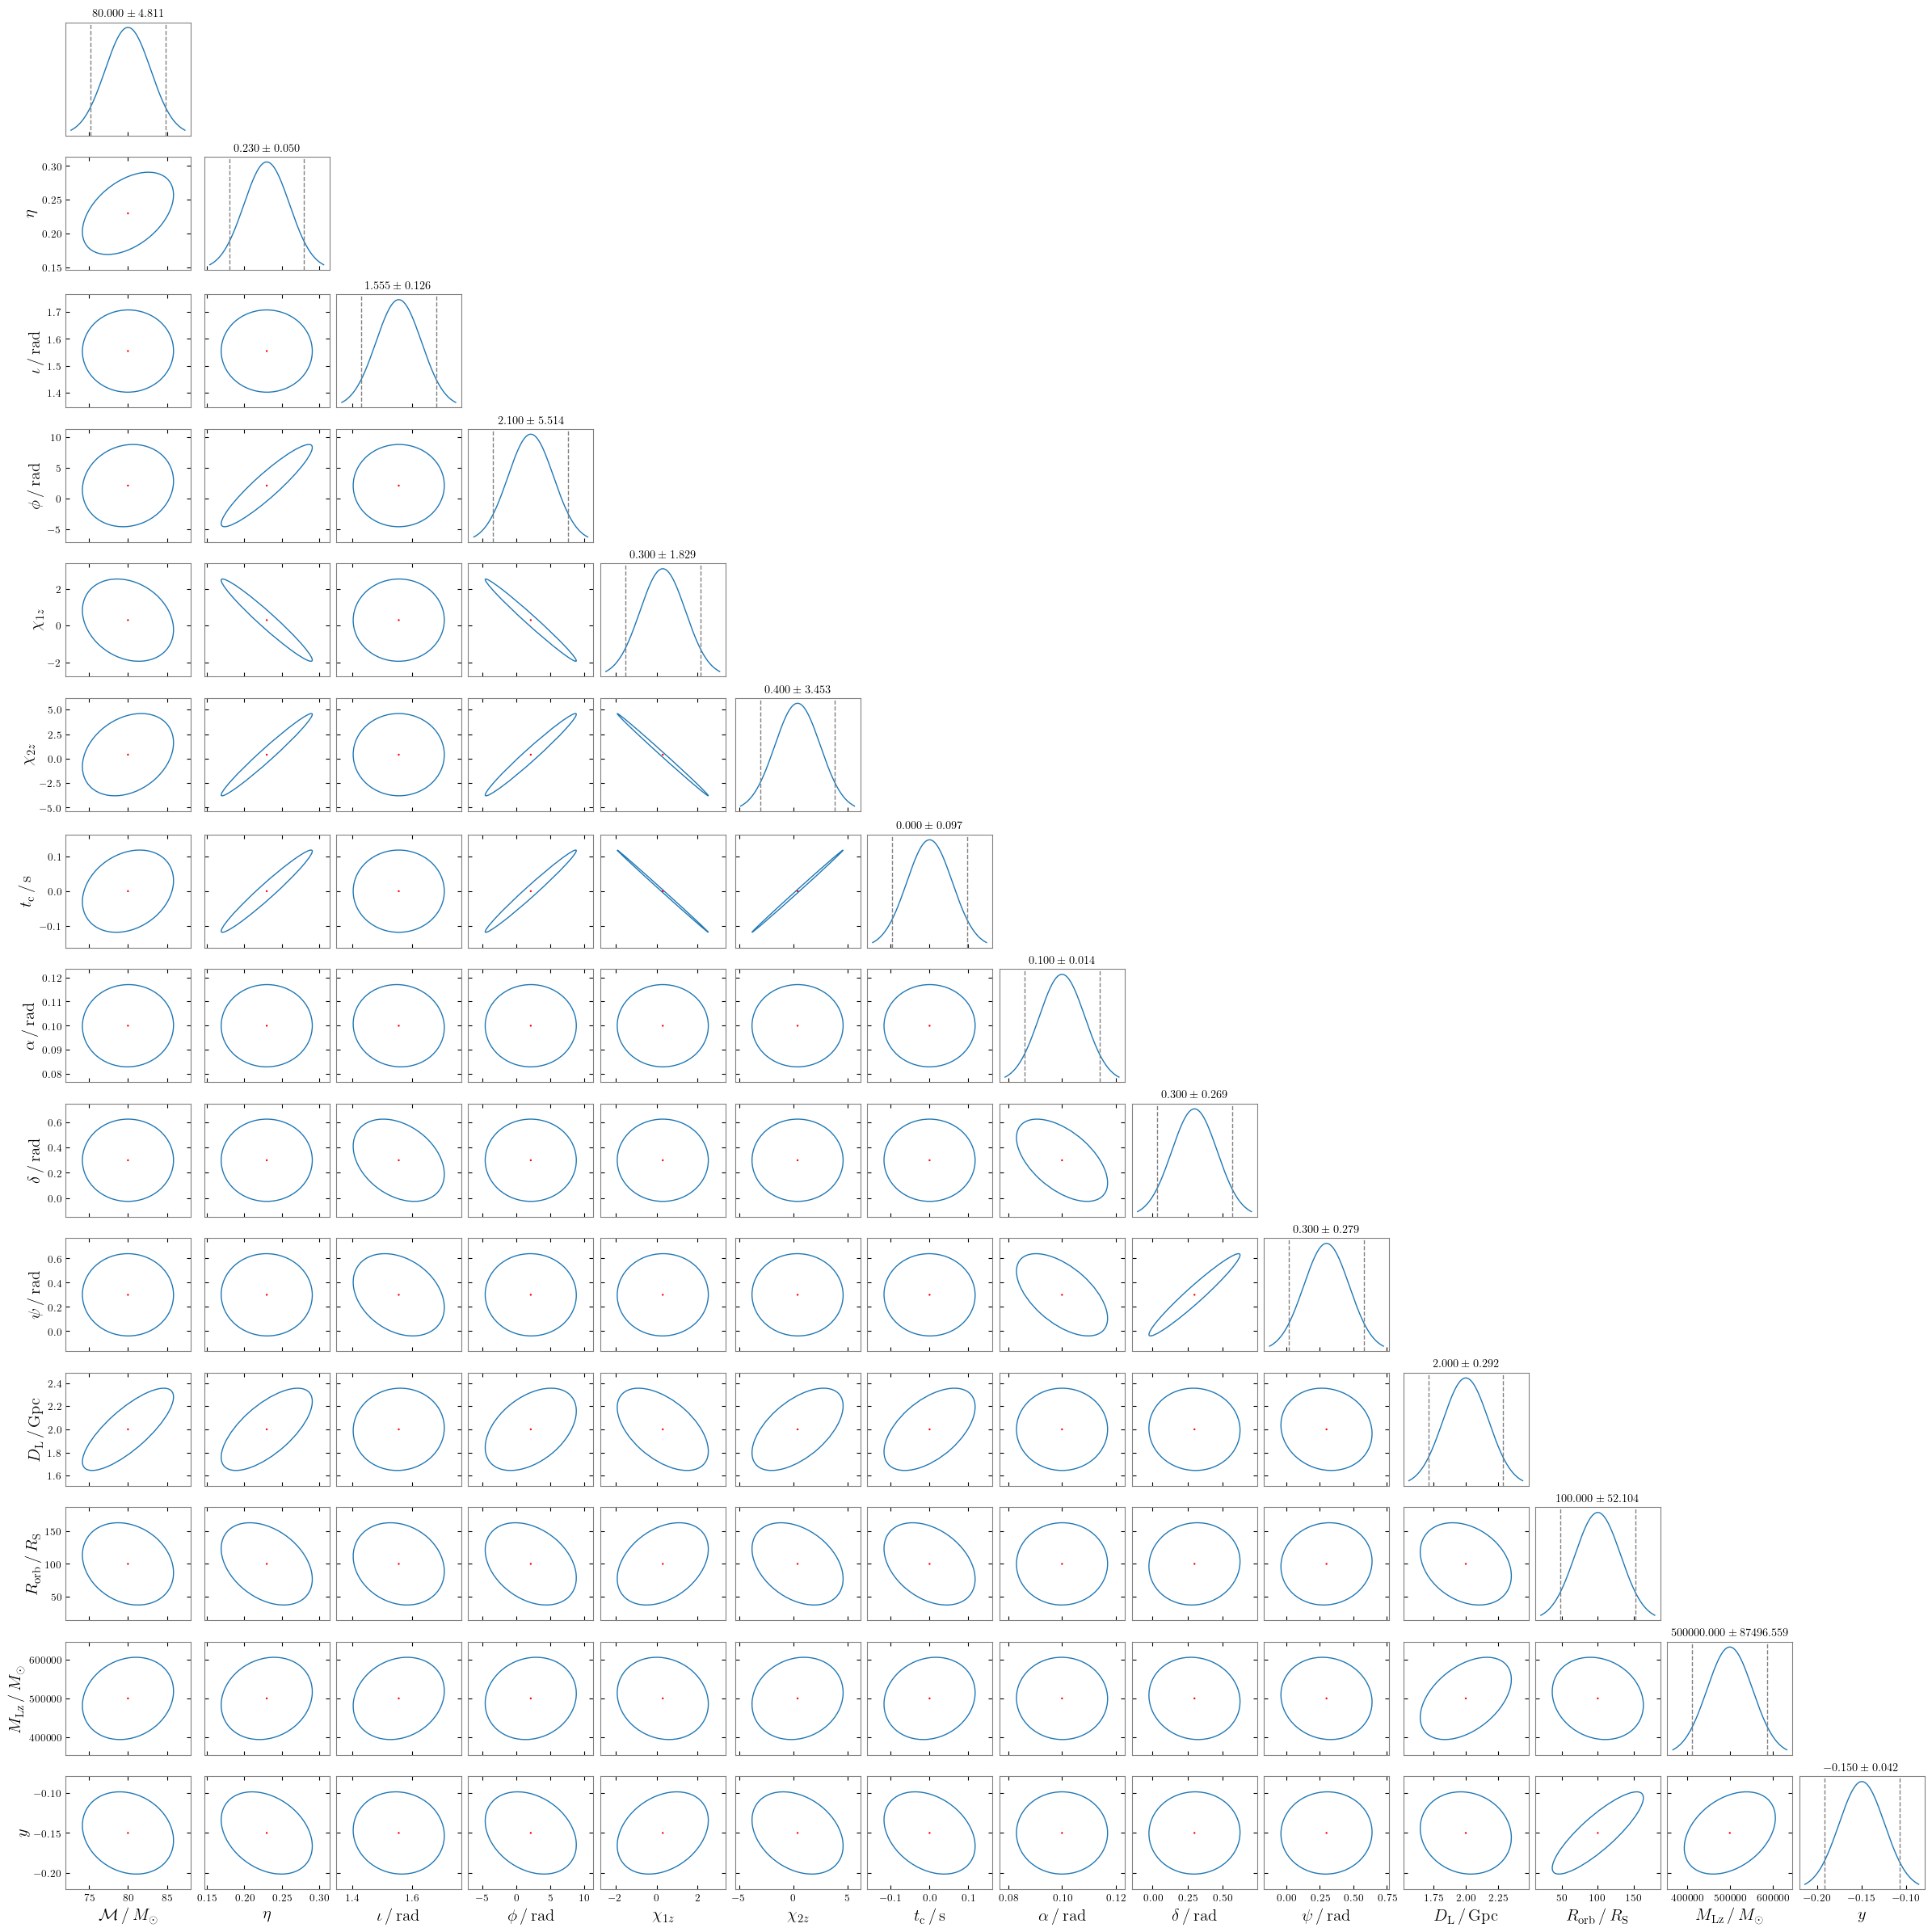

In [9]:
idx = 1
indices = np.arange(0, len(keys))
parameters = {key: val[idx] for key, val in lensing_parameters.items()}
# parameters['delta_time'] *= DAY_TO_SEC 

fig = plot_corners(
    reduced_cov_mats[:, :, idx], keys, indices, 
    event=parameters, labels=labels, color='C0'
)

In [ ]:
sub_lensing_parameters = {key: lensing_parameters[key] for 
                          key in ['iota', 'R_orbit', 'src_pos', 'M_lz', 'dL']}
jax.vmap(jax.jacfwd(lensing_transform))(sub_lensing_parameters)

{'delta_incl': {'M_lz': Array([-5.50796102e-23, -5.45246378e-23, -5.33973918e-23], dtype=float64),
  'R_orbit': Array([4.43769085e-04, 1.46432582e-04, 8.60431350e-05], dtype=float64),
  'dL': Array([1.69091723e-17, 1.67387985e-17, 1.63927395e-17], dtype=float64),
  'iota': Array([5.65117301, 1.86474426, 1.09571545], dtype=float64),
  'src_pos': Array([-1.77952515, -0.19973754, -0.07342348], dtype=float64)},
 'delta_phi': {'M_lz': Array([1.66683867e-22, 5.23821099e-22, 8.76127051e-22], dtype=float64),
  'R_orbit': Array([-0.00134295, -0.00140679, -0.00141177], dtype=float64),
  'dL': Array([-5.11711363e-17, -1.60810529e-16, -2.68966742e-16], dtype=float64),
  'iota': Array([1.86363521, 0.18972957, 0.06236158], dtype=float64),
  'src_pos': Array([-0.58817774, -0.02079585, -0.00447605], dtype=float64)},
 'delta_time': {'M_lz': Array([1.18976206e-10, 3.73151187e-10, 6.74159976e-10], dtype=float64),
  'R_orbit': Array([3.00498221e-07, 1.01119217e-06, 2.01985750e-06], dtype=float64),
  'dL':

In [14]:
reduce_fisher_mat.shape, keys

((14, 14, 3),
 ['Mc',
  'eta',
  'iota',
  'phase',
  'chi1z',
  'chi2z',
  'tcoal',
  'theta',
  'phi',
  'psi',
  'dL',
  'R_orbit',
  'M_lz',
  'src_pos'])

In [22]:
from collections import OrderedDict
from jax import tree

def high_dim_matmul(mat_1, mat_2):
    """
    Perform matrix multiplication for high-dimensional arrays.
    The first two dimensions of the input arrays are treated as matrices.
    """
    return onp.einsum('ij...,jk...->ik...', mat_1, mat_2)

def fisher_change_variable(fisher_matrix, injection_parameters, transform, from_params):
    injection_parameters = lensing_parameters.copy()
    sub_injection_parameters = OrderedDict(
        {key: injection_parameters[key] for key in from_params})
    jacobian_dict = jax.vmap(jax.jacfwd(transform))(sub_injection_parameters)
    transform_dim = len(from_params)
    param_shape = fisher_matrix.shape[2:]
    jacobian_mat = np.array(tree.leaves(jacobian_dict)).reshape(
        transform_dim, transform_dim, *param_shape)
    # _jacobian_mat = np.moveaxis(jacobian_mat, [0, 1], [-2, -1])
    # inv_jacobian_mat = onp.linalg.inv(_jacobian_mat)
    # inv_jacobian_mat = onp.moveaxis(inv_jacobian_mat, [-2, -1], [0, 1])

    matrix_keys = list(injection_parameters.keys())
    keys_indices = [matrix_keys.index(key) for key in from_params]

    # Compute transformed Fisher matrix
    full_rank = fisher_matrix.shape[0]
    full_jacobian_mat = onp.zeros_like(fisher_matrix)
    full_jacobian_mat[onp.diag_indices(full_rank)] = 1.0
    full_jacobian_mat[onp.ix_(keys_indices, keys_indices)] = jacobian_mat
    full_jacobian_mat_T = onp.transpose(
        full_jacobian_mat, axes=(1, 0, *range(2, full_jacobian_mat.ndim)))
    transform_fisher = high_dim_matmul(
        full_jacobian_mat, high_dim_matmul(
            fisher_matrix, full_jacobian_mat_T))
    
    # Compute transformed parameters and keys
    sub_transformed_parameters = transform(sub_injection_parameters)
    transform_keys = matrix_keys.copy()
    for idx, new_key_name in zip(keys_indices, sub_transformed_parameters.keys()):
        transform_keys[idx] = new_key_name
    transform_parameters = {}
    for key in transform_keys:
        value = injection_parameters.get(key, None)
        if value is None:
            value = sub_transformed_parameters.get(key, None)
        transform_parameters[key] = value

    return transform_fisher, transform_parameters, transform_keys


# transformed_fisher, transformed_parameters, transformed_keys = fisher_change_variable(
#     reduce_fisher_mat, lensing_parameters, lensing_transform, 
#     ['iota', 'R_orbit', 'src_pos', 'M_lz', 'dL']
# )
# transformed_cov_mat, ie = compute_covariance_matrix(transformed_fisher)

# idx = 1
# indices = np.arange(0, len(transformed_keys))
# parameters = {key: val[idx] for key, val in transformed_parameters.items()}
# # parameters['delta_time'] *= DAY_TO_SEC 

# fig = plot_corners(
#     transformed_cov_mat[:, :, idx], transformed_keys, indices, 
#     event=parameters, labels=labels, color='C0'
# )

/users/hin-wai.leong/.conda/envs/180125_py311_AGNLensing/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


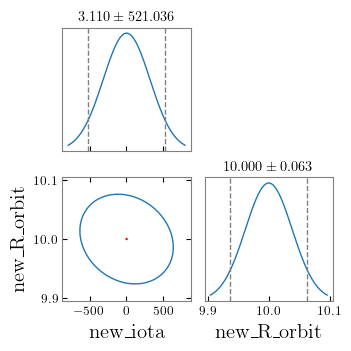

In [27]:
def simple_transform(injection_parameters):
    return {
        'new_iota': injection_parameters['iota'] * 2,
        'new_R_orbit': injection_parameters['R_orbit'] / 10,
    }


# transformed_cov_mat, transformed_parameters, transformed_keys = fisher_change_variable(
#     reduced_cov_mats, lensing_parameters, simple_transform, 
#     ['iota', 'R_orbit']
# )
transformed_fisher, transformed_parameters, transformed_keys = fisher_change_variable(
    reduce_fisher_mat, lensing_parameters, simple_transform, 
    ['iota', 'R_orbit']
)
transformed_cov_mat, ie = compute_covariance_matrix(transformed_fisher)

idx = 1
indices = np.arange(0, len(transformed_keys))
indices = np.array([2, 11])
parameters = {key: val[idx] for key, val in transformed_parameters.items()}
_keys = [transformed_keys[i] for i in indices]
# parameters['delta_time'] *= DAY_TO_SEC 

fig = plot_corners(
    transformed_cov_mat[:, :, idx], _keys, indices, 
    event=parameters, labels=labels, color='C0'
)

In [26]:
transformed_fisher - reduce_fisher_mat

array([[[ 4.60083660e+13,  2.07897207e+13,  1.66418103e+13],
        [-2.29658668e+13, -1.03775475e+13, -8.30704782e+12],
        [-1.63747746e+08, -2.29364002e+07, -2.86838283e+07],
        [ 3.75428252e+08,  1.69535657e+08,  1.35727614e+08],
        [-8.64803068e+09, -3.90842986e+09, -3.11721394e+09],
        [-2.24912999e+08, -9.23823202e+07, -6.63667401e+07],
        [-1.60188726e+11, -7.25270228e+10, -5.78419365e+10],
        [-1.01039725e+09, -4.55306387e+08, -3.61914999e+08],
        [-1.77076315e+08, -8.44082511e+07, -6.96333847e+07],
        [ 5.59728972e+06,  6.64906204e+06,  7.53354590e+06],
        [ 6.44230195e+10,  1.17106303e+11,  1.84197162e+11],
        [-2.85358735e+09, -5.56725962e+09, -9.68245334e+09],
        [-1.13022380e+06, -2.05462792e+06, -3.23176753e+06],
        [ 1.14313361e+13,  7.50850775e+12,  8.00387470e+12]],

       [[-2.29658668e+13, -1.03775475e+13, -8.30704782e+12],
        [ 1.14637620e+13,  5.18011136e+12,  4.14659043e+12],
        [ 8.15750724e+

['mass_1', 'mass_2'] [0 1]


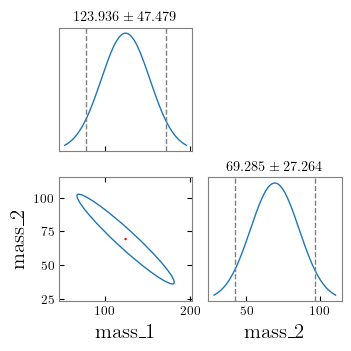

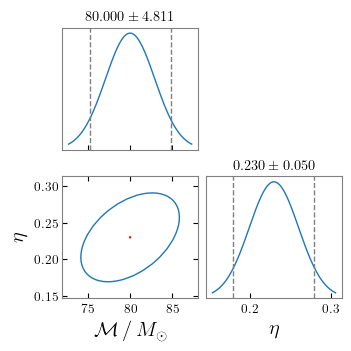

In [28]:
def simple_transform(injection_parameters):
    m1, m2 = m1m2_from_Mceta(
        injection_parameters['Mc'], injection_parameters['eta']
    )
    return {
        'mass_1': m1, 'mass_2': m2,
    }


# transformed_fisher, transformed_parameters, transformed_keys = fisher_change_variable(
#     reduce_fisher_mat, lensing_parameters, simple_transform, ['Mc', 'eta']
# )
# transformed_cov_mat, ie = compute_covariance_matrix(transformed_fisher)
transformed_cov_mat, transformed_parameters, transformed_keys = fisher_change_variable(
    reduced_cov_mats, lensing_parameters, simple_transform, 
    ['Mc', 'eta']
)

idx = 1
indices = np.arange(0, len(transformed_keys))
indices = np.array([0, 1])
parameters = {key: val[idx] for key, val in transformed_parameters.items()}
# parameters['delta_time'] *= DAY_TO_SEC 

_keys = [transformed_keys[i] for i in indices]
print(_keys, indices)
fig = plot_corners(
    transformed_cov_mat[:, :, idx], _keys, indices, 
    event=parameters, labels=labels, color='C0'
)

_keys = list(lensing_parameters.keys()).copy()
_keys = [_keys[i] for i in indices]
parameters = {key: val[idx] for key, val in lensing_parameters.items()}
fig = plot_corners(
    reduced_cov_mats[:, :, idx], _keys, indices, 
    event=parameters, labels=labels, color='C0'
)

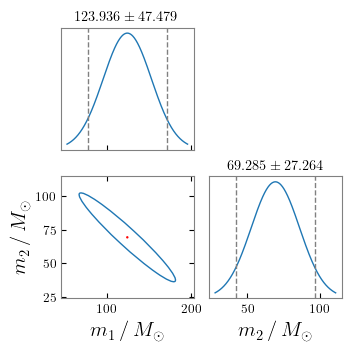

In [17]:
trans_cov_mat, ie = compute_covariance_matrix(trans_HLV_fisher)

indices = [-2, -1]
_keys = list(trans_lensing_parameters.keys()).copy()
_keys = [_keys[i] for i in indices]
parameters = {key: val[idx] for key, val in trans_lensing_parameters.items()}
fig = plot_corners(
    trans_cov_mat[:, :, idx], _keys, indices, 
    event=parameters, labels=labels, color='C0'
)

In [14]:
shape = 3
trans_lensing_parameters = lensing_parameters.copy()
Mc = trans_lensing_parameters.pop('Mc')
eta = trans_lensing_parameters.pop('eta')

m1, m2 = m1m2_from_Mceta(Mc, eta)
trans_lensing_parameters['m1'] = m1
trans_lensing_parameters['m2'] = m2

trans_lensing_parameters = {key: np.full(shape, val).astype(np.float64) for key, val in trans_lensing_parameters.items()}
trans_lensing_parameters['src_pos'] = - np.arange(1, 6, 2) * 0.05
sub_trans_lensing_parameters = {key: val[idx] for key, val in trans_lensing_parameters.items()}

trans_HLV_fisher = HLV_AGN.FisherMatr(sub_trans_lensing_parameters, res=1000)

Computing Fisher for H1...
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 17.65215266133077, Maximum duration: 32.75541455272001.



KeyboardInterrupt: 

In [60]:
lensing_parameters

{'Mc': Array([80., 80., 80.], dtype=float64),
 'eta': Array([0.23, 0.23, 0.23], dtype=float64),
 'iota': Array([1.55508836, 1.55508836, 1.55508836], dtype=float64),
 'phase': Array([2.1, 2.1, 2.1], dtype=float64),
 'chi1z': Array([0.3, 0.3, 0.3], dtype=float64),
 'chi2z': Array([0.4, 0.4, 0.4], dtype=float64),
 'tcoal': Array([0., 0., 0.], dtype=float64),
 'theta': Array([0.1, 0.1, 0.1], dtype=float64),
 'phi': Array([0.3, 0.3, 0.3], dtype=float64),
 'psi': Array([0.3, 0.3, 0.3], dtype=float64),
 'dL': Array([2., 2., 2.], dtype=float64),
 'R_orbit': Array([100., 100., 100.], dtype=float64),
 'M_lz': Array([500000., 500000., 500000.], dtype=float64),
 'src_pos': Array([-0.05, -0.15, -0.25], dtype=float64, weak_type=True)}

In [25]:
mat = onp.identity(5)
mat[onp.ix_([1, 4], [1, 4])] = 10
mat

array([[ 1.,  0.,  0.,  0.,  0.],
       [ 0., 10.,  0.,  0., 10.],
       [ 0.,  0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  1.,  0.],
       [ 0., 10.,  0.,  0., 10.]])

In [38]:
sub_array = onp.arange(1, 5).reshape(2, 2)
sub_array = sub_array[:, :, None] * np.arange(1, 4)

In [40]:
mat = onp.zeros((5, 5, 3))
diag_idx = np.diag_indices(5)
mat[diag_idx] = 1
mat[onp.ix_([1, 4], [1, 4])] = sub_array
mat[:, :, 1]

array([[1., 0., 0., 0., 0.],
       [0., 2., 0., 0., 4.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 6., 0., 0., 8.]])

## Empirical test with sampling